# Walkthrough: can Google searches predict Duolingo's user growth?

Duolingo reports daily active users (DAUs) once a quarter, weeks after the quarter ends. Google search interest updates every week. If one tracked the other, an investor could see a user-growth surprise coming before the earnings release.

This notebook walks through the test step by step. The heavy lifting lives in `src/analysis.py`; here I explain each step and what the results mean. I hold Duolingo myself, so this was also a way to check the growth story with data.

In [1]:
import sys
sys.path.insert(0, "src")
import pandas as pd
import matplotlib.pyplot as plt
from analysis import build_quarterly, walk_forward, nowcast

df = build_quarterly("duolingo")
df[["kpi", "trends"]].dropna(how="all").rename(columns={"kpi": "dau"}).round(1)

,dau,trends
2021Q4,10.1,33.2
2022Q1,NaN,44.7
2022Q2,NaN,46.5
2022Q3,14.9,49.8
2022Q4,16.3,52.1
2023Q1,20.3,61.5
2023Q2,21.4,56.3
2023Q3,24.2,59.7
2023Q4,26.9,55.9
2024Q1,31.4,60.5


## 1. The raw picture

`dau` is reported daily active users in millions, from Duolingo's shareholder letters (sources in `companies/duolingo/kpi.csv`). `trends` is average weekly Google search interest for "Duolingo", worldwide, on Google's 0 to 100 scale.

Plotting both levels on one chart already shows the main story.

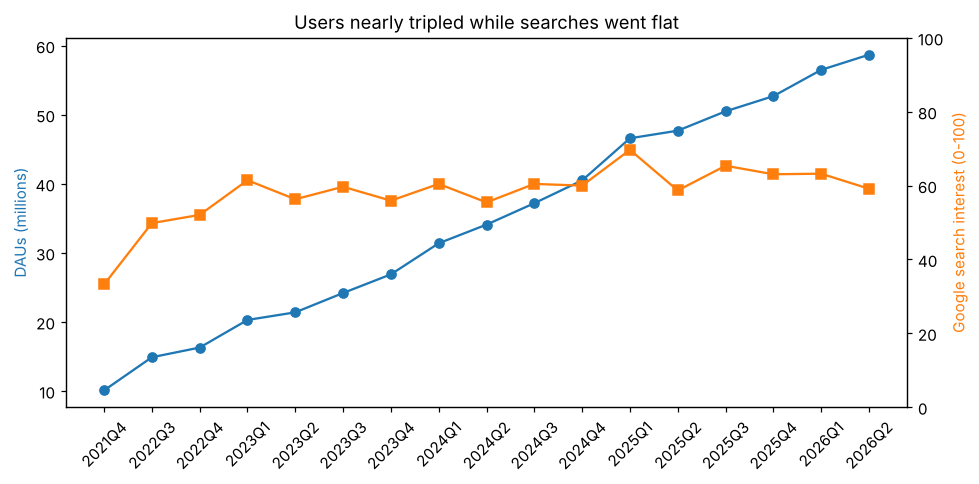

In [2]:
lv = df[["kpi", "trends"]].dropna()
fig, ax1 = plt.subplots(figsize=(9, 4.5))
x = [str(p) for p in lv.index]
ax1.plot(x, lv["kpi"], marker="o", color="tab:blue", label="DAUs (millions)")
ax1.set_ylabel("DAUs (millions)", color="tab:blue")
ax2 = ax1.twinx()
ax2.plot(x, lv["trends"], marker="s", color="tab:orange", label="Search interest")
ax2.set_ylabel("Google search interest (0-100)", color="tab:orange")
ax2.set_ylim(0, 100)
ax1.set_title("Users nearly tripled while searches went flat")
ax1.tick_params(axis="x", rotation=45)
fig.tight_layout()

Between Q2 2023 and Q2 2026, DAUs went from 21.4M to 58.7M while search interest stayed in a band of roughly 55 to 65. That is the first sign that searches are not where the growth comes from.

## 2. Compare growth, not levels

Two series that both trend upward will look correlated whether or not one predicts the other. So I compare year-over-year (YoY) growth, which also strips out seasonality like the January resolution spike.

Quarters with both growth rates: 13
Correlation of YoY growth: 0.45


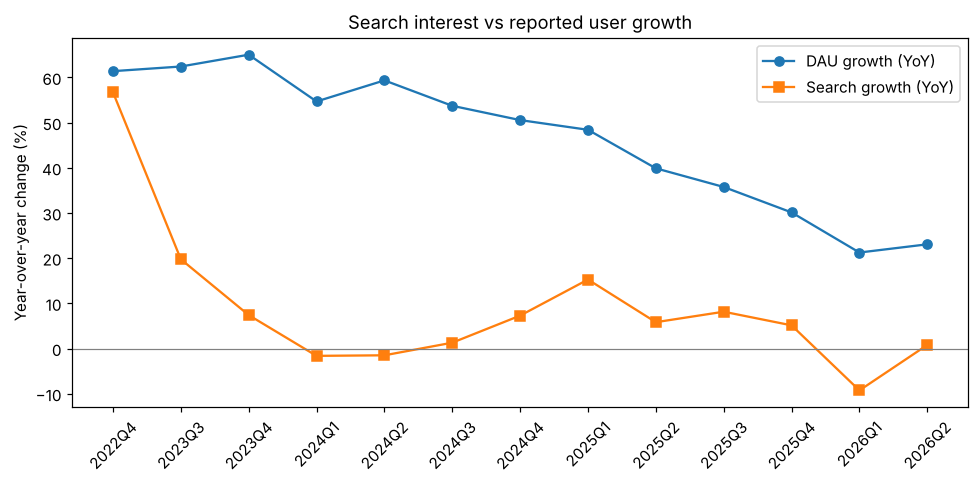

In [3]:
g = df.dropna(subset=["kpi_yoy", "trends_yoy"])
print(f"Quarters with both growth rates: {len(g)}")
print(f"Correlation of YoY growth: {g['kpi_yoy'].corr(g['trends_yoy']):.2f}")

fig, ax = plt.subplots(figsize=(9, 4.5))
x = [str(p) for p in g.index]
ax.plot(x, g["kpi_yoy"] * 100, marker="o", label="DAU growth (YoY)")
ax.plot(x, g["trends_yoy"] * 100, marker="s", label="Search growth (YoY)")
ax.axhline(0, color="grey", lw=0.8)
ax.set_ylabel("Year-over-year change (%)")
ax.set_title("Search interest vs reported user growth")
ax.legend(); ax.tick_params(axis="x", rotation=45)
fig.tight_layout()

A correlation of 0.45 sounds decent, but the chart shows why it is misleading: both lines drift down over time, while search growth hovers near zero from 2024 and does not call the quarter-to-quarter turns in DAU growth.

## 3. The real test: out-of-sample forecasts

For each quarter, I fit the model only on earlier quarters and predict that quarter, which is what an analyst could actually have done before the release. Two models:

- **Search-level:** DAU growth regressed on search growth.
- **Search-change:** last quarter's DAU growth, nudged by how much search growth moved since then.

Both have to beat a naive benchmark that assumes DAU growth stays the same as last quarter.

In [4]:
wf = walk_forward(df)
mae = lambda col: (wf[col] - wf["actual"]).abs().mean()
summary = pd.DataFrame({
    "Model": ["Naive benchmark", "Search-level", "Search-change"],
    "Mean abs. error (M DAUs)": [mae("naive"), mae("level_model"), mae("change_model")],
}).round(2)
summary["vs benchmark"] = (summary["Mean abs. error (M DAUs)"] / summary.iloc[0, 1] - 1).map("{:+.0%}".format)
summary

,Model,Mean abs. error (M DAUs),vs benchmark
0,Naive benchmark,1.89,+0%
1,Search-level,7.05,+273%
2,Search-change,1.97,+4%


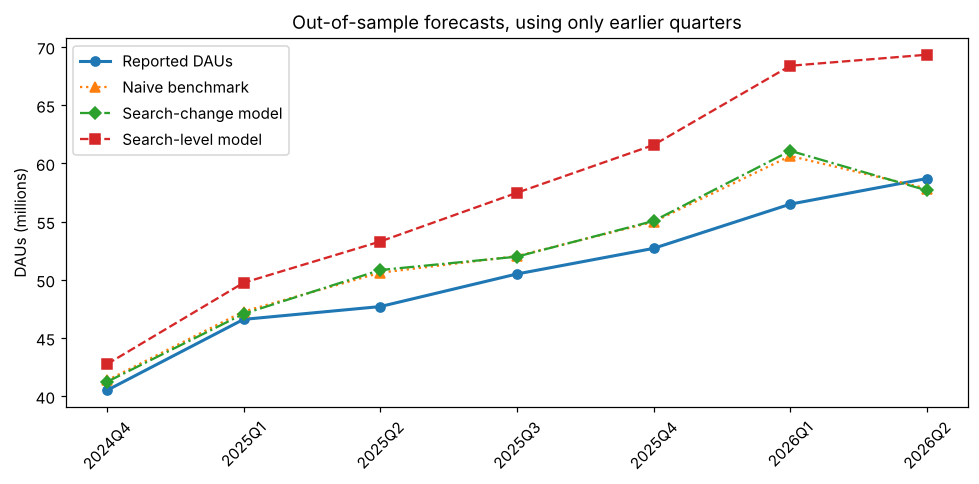

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(wf["quarter"], wf["actual"], marker="o", lw=2, label="Reported DAUs")
ax.plot(wf["quarter"], wf["naive"], marker="^", ls=":", label="Naive benchmark")
ax.plot(wf["quarter"], wf["change_model"], marker="D", ls="-.", label="Search-change model")
ax.plot(wf["quarter"], wf["level_model"], marker="s", ls="--", label="Search-level model")
ax.set_ylabel("DAUs (millions)")
ax.set_title("Out-of-sample forecasts, using only earlier quarters")
ax.legend(); ax.tick_params(axis="x", rotation=45)
fig.tight_layout()

Neither model beats the benchmark. The search-change model is close (about 4% worse), which means search added almost nothing beyond the existing trend. The search-level model is far off because it learned the 2022 relationship, when searches and users both grew around 60%, and kept forecasting growth that searches no longer supported.

## 4. A prediction before the next release

Q3 2026 ended on 30 September and Duolingo has not reported yet. Here is what each approach implies, recorded before the release.

In [6]:
nc = nowcast(df)
print(f"Quarter: {nc['quarter']}   Search interest YoY: {nc['trends_yoy']:+.1%}")
print(f"Naive benchmark:      {nc['naive']:.1f}M DAUs ({nc['naive_yoy']:.1%} YoY)")
print(f"Search-change model:  {nc['change_model']:.1f}M DAUs ({nc['change_yoy']:.1%} YoY)")
print(f"Search-level model:   {nc['level_model']:.1f}M DAUs ({nc['level_yoy']:.1%} YoY), not trusted given its record")

Quarter: 2026Q3   Search interest YoY: -12.8%
Naive benchmark:      62.1M DAUs (23.1% YoY)
Search-change model:  62.0M DAUs (22.9% YoY)
Search-level model:   69.4M DAUs (37.4% YoY), not trusted given its record


My call is about **62M DAUs**. I'll record the reported number in the README after the release.

## What I take from this

- **Worldwide Google search is not a useful DAU signal for Duolingo after 2023.** Testing it properly against a benchmark is what showed that; the correlation alone would have suggested otherwise.
- **The failure is informative.** Users kept growing while searches stayed flat, so growth is probably not coming from people discovering Duolingo on Google. A more likely driver is existing users returning more often (streaks, notifications) and installs through app stores and social media. That is a hypothesis this data cannot prove by itself.
- **Next steps:** try signals closer to the product (app store rankings, Wikipedia page views), split search by country, and compare DAU/MAU with search to test the retention story directly.

**Limitations:** 13 quarters of growth data and 7 out-of-sample tests is a small sample, Google Trends is relative and sampled, and worldwide search blends very different markets.